In [1]:
import pickle
import numpy as np
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
with open('../data/processed/data_splits.pkl', 'rb') as f:
    data = pickle.load(f)

X_train = data['X_train']
X_val = data['X_val']
X_test = data['X_test']
y_train = data['y_train']
y_val = data['y_val']
y_test = data['y_test']
le = data['label_encoder']

print(f"Train: {X_train.shape}")
print(f"Val  : {X_val.shape}")
print(f"Test : {X_test.shape}")
print(f"Classes: {le.classes_}")

Train: (79845, 50000)
Val  : (17110, 50000)
Test : (17110, 50000)
Classes: ['Critical' 'Low' 'Medium']


In [3]:
mnb_model = MultinomialNB(alpha=0.1)
mnb_model.fit(X_train, y_train)

# Evaluasi di validation set
y_val_pred_mnb = mnb_model.predict(X_val)
val_acc_mnb = accuracy_score(y_val, y_val_pred_mnb)
print(f"Validation Accuracy (MNB): {val_acc_mnb*100:.2f}%")

Validation Accuracy (MNB): 74.52%


In [4]:
cnb_model = ComplementNB(alpha=0.1)
cnb_model.fit(X_train, y_train)

# Evaluasi di validation set
y_val_pred_cnb = cnb_model.predict(X_val)
val_acc_cnb = accuracy_score(y_val, y_val_pred_cnb)
print(f"Validation Accuracy (CNB): {val_acc_cnb*100:.2f}%")

print(f"\nPerbandingan Validation Accuracy:")
print(f"Multinomial NB : {val_acc_mnb*100:.2f}%")
print(f"Complement NB  : {val_acc_cnb*100:.2f}%")

Validation Accuracy (CNB): 74.07%

Perbandingan Validation Accuracy:
Multinomial NB : 74.52%
Complement NB  : 74.07%


In [5]:
y_test_pred_mnb = mnb_model.predict(X_test)

print("Evaluasi Multinomial Naïve Bayes di Test Set:")
print(f"\nAccuracy: {accuracy_score(y_test, y_test_pred_mnb)*100:.2f}%")
print(f"\nClassification Report:")
print(classification_report(y_test, y_test_pred_mnb, target_names=le.classes_))

Evaluasi Multinomial Naïve Bayes di Test Set:

Accuracy: 74.59%

Classification Report:
              precision    recall  f1-score   support

    Critical       0.57      0.38      0.46      1119
         Low       0.72      0.77      0.74      6779
      Medium       0.78      0.77      0.78      9212

    accuracy                           0.75     17110
   macro avg       0.69      0.64      0.66     17110
weighted avg       0.74      0.75      0.74     17110



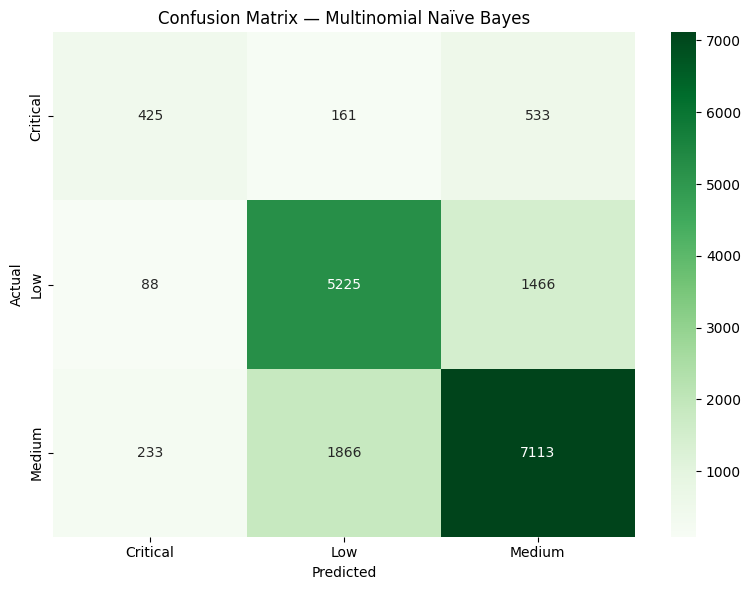

In [6]:
cm_mnb = confusion_matrix(y_test, y_test_pred_mnb)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_mnb, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Confusion Matrix — Multinomial Naïve Bayes')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [7]:
# Simpan MNB model
with open('../data/processed/mnb_model.pkl', 'wb') as f:
    pickle.dump(mnb_model, f)

print("\nSummary Perbandingan Linear Regression vs Naïve Bayes:")
print(f"{'Metric':<25} {'LR':>10} {'MNB':>10}")
print("-" * 45)
print(f"{'Accuracy':<25} {'80.36%':>10} {'74.59%':>10}")
print(f"{'F1 Critical':<25} {'0.76':>10} {'0.46':>10}")
print(f"{'F1 Low':<25} {'0.79':>10} {'0.74':>10}")
print(f"{'F1 Medium':<25} {'0.82':>10} {'0.78':>10}")
print(f"{'F1 Macro Avg':<25} {'0.79':>10} {'0.66':>10}")
print("-" * 45)


Summary Perbandingan Linear Regression vs Naïve Bayes:
Metric                            LR        MNB
---------------------------------------------
Accuracy                      80.36%     74.59%
F1 Critical                     0.76       0.46
F1 Low                          0.79       0.74
F1 Medium                       0.82       0.78
F1 Macro Avg                    0.79       0.66
---------------------------------------------
